Description provided by the creator of the dataset:

Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.

Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.

DATA Source: IBM

The objective of this project is to build a supervised machine learning model that predicts the most appropriate drug for a patient based on their clinical and demographic characteristics.

This is a multi-class classification problem, where the target variable is the prescribed drug.

The dataset contains the following patient information:

Age \
Sex\
Blood Pressure (BP)\
Cholesterol\
Sodium-to-Potassium ratio (Na_to_K)\
Drug (target variable)

In [1]:
import pandas as pd
import numpy as np
import seaborn.objects as so
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
drugs = pd.read_csv('/home/martingalan/Documentos/PROYECTOS_DS/DATASETS/Drugs_A,_B,_C,_X,_Y_for_Decision_Trees/drug200.csv')
drugs

In [23]:
drugs.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [26]:
print(drugs.Sex.unique(),drugs.BP.unique(),drugs.Cholesterol.unique(),drugs.Drug.unique())

<StringArray>
['F', 'M']
Length: 2, dtype: str <StringArray>
['HIGH', 'LOW', 'NORMAL']
Length: 3, dtype: str <StringArray>
['HIGH', 'NORMAL']
Length: 2, dtype: str <StringArray>
['drugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str


No null data.\
 All looks good.

I'll continue with the training of the model. Further analysis (EDA) at the end of this notebook.

**Preprocessing: column & label encoding**

In [6]:
X = drugs.drop(columns='Drug')
y = drugs.Drug

In [7]:
le = LabelEncoder()
y = le.fit_transform(y)

numeric_cols = ['Age', 'Na_to_K']
ordinal_cols = ['BP', 'Cholesterol']
categorical_cols = ['Sex']

In [8]:
preprocess = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[['LOW', 'NORMAL', 'HIGH'],
                        ['LOW', 'NORMAL', 'HIGH']]
        ), ordinal_cols),

        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'  # leaves Age and Na_to_K as they are
)

**Model training with RandomForestClassifier + GridSearchCV**

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

RandomForestClassifier is a great solution for this problem

In [10]:

model = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(random_state=42))
])


#TTS

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#GridSearchCV

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 5, 10, 20],
    'clf__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [None, 5, ...], 'clf__min_samples_split': [2, 5, ...], 'clf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [11]:
best_model = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

{'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
0.9875


In [12]:

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



**Checking with confussion matrix**

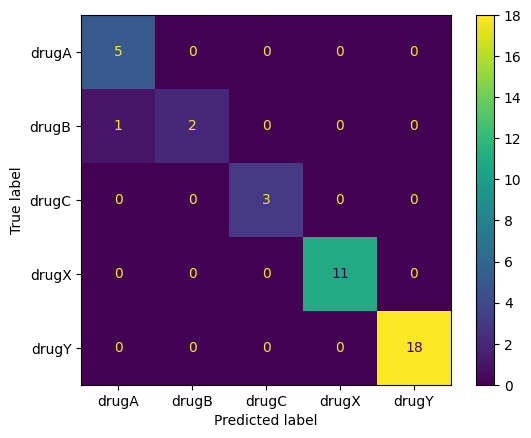

In [13]:

label_names = le.classes_

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_names
)

plt.show()

In [16]:

X_hand = pd.DataFrame([{
    'Age': 45,
    'Sex': 'M',
    'BP': 'HIGH',
    'Cholesterol': 'NORMAL',
    'Na_to_K': 15.2
}])

y_pred_hand = best_model.predict(X_hand)

y_pred_hand


array([4])

**Post Training EDA**

Trying values by hand I noticed that is usual to get drug number 4 (drugY). Why?

Text(0.5, 1.0, 'Drugs Classes distribution')

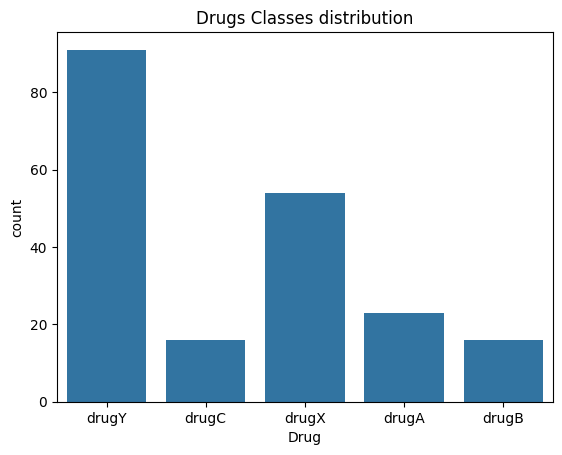

In [17]:
sns.countplot(data=drugs, x='Drug')
plt.title("Drugs Classes distribution")

Notice that it is, in fact, unbalanced. drugY is more common than the others.

What's the relation between Age and Drug?

Text(0.5, 1.0, 'Age by drug class')

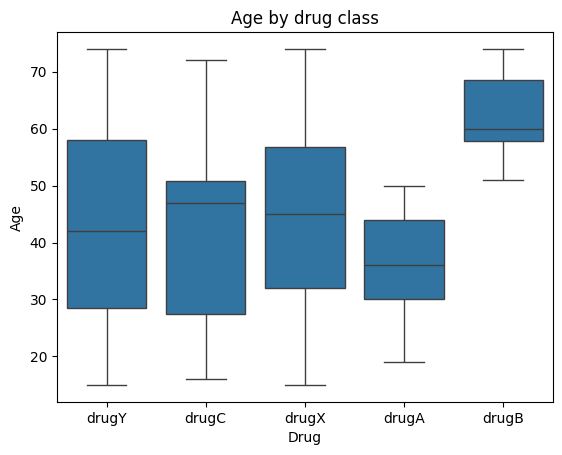

In [18]:
sns.boxplot(data=drugs, x='Drug', y='Age')
plt.title("Age by drug class")

As I can see, drugB has the highest age mean.

Text(0.5, 1.0, 'Na_to_K vs Drug segmented by BP')

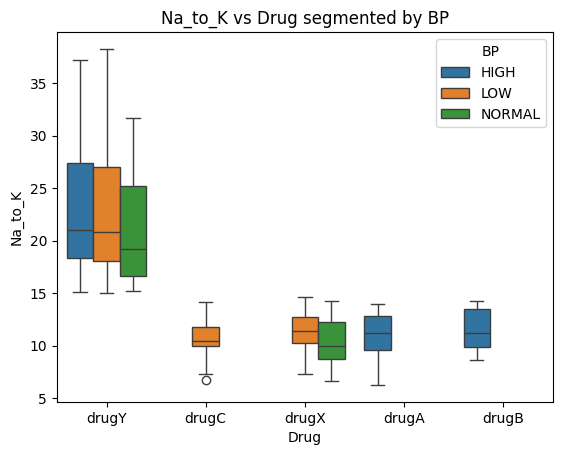

In [27]:
sns.boxplot(data=drugs, x='Drug', y='Na_to_K', hue='BP')
plt.title("Na_to_K vs Drug segmented by BP")

I can observe that BP and Na/K ratio are determinant for the separation of drugs. This is responsible for the accuracy in the RandomForest model for this dataset.

**ANOVA** \
Understanding separation between groups (formally)

In [20]:
from scipy.stats import f_oneway

for col in ['Age', 'Na_to_K']:
    groups = [drugs[drugs['Drug'] == d][col] for d in drugs['Drug'].unique()]
    print(col, f_oneway(*groups))

Age F_onewayResult(statistic=np.float64(7.210544266570636), pvalue=np.float64(1.9560981046228137e-05))
Na_to_K F_onewayResult(statistic=np.float64(85.61135649670533), pvalue=np.float64(7.429679925437972e-42))


The p-value for the Na/K ratio is really small and the F number is great (that's not the case for 'Age'.). This proves the separation is real.

In [22]:
from scipy.stats import chi2_contingency

for col in ['BP', 'Cholesterol', 'Sex','Sex']:
    table = pd.crosstab(drugs[col], drugs['Drug'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(col,chi2,p)

BP 143.23287184969993 5.041733414466518e-27
Cholesterol 19.609657681313468 0.0005962588389856516
Sex 2.119248418109203 0.7138369773987128
Sex 2.119248418109203 0.7138369773987128


High correlation between BP and Drug. Same goes to Cholesterol.

**Final Thougts**

The model achieved high performance in the following classification metrics:

High overall accuracy \
Low confusion between well-separated classes

The most influential features were (in order of importance):

Na_to_K (Sodium-to-Potasium ratio)\
BP (Blood Pressure) \
Cholesterol \
Age \
Sex